# 8. Planner

![Swarm](docs/planner.png)

## Define Tools

We will first define the tools we want to use. For this simple example, we will use a built-in search tool via Tavily. However, it is really easy to create your own tools - see documentation [here](https://python.langchain.com/docs/how_to/custom_tools) on how to do that.

In [1]:
from langchain_tavily import TavilySearch

tavily_tool = TavilySearch()
tools = [tavily_tool]

Example invocation of the tool itself

In [2]:
tavily_tool.invoke("What is the capital of France?")

{'query': 'What is the capital of France?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://en.wikipedia.org/wiki/List_of_capitals_of_France',
   'title': 'List of capitals of France - Wikipedia',
   'content': 'The capital of France has been Paris since its liberation in 1944.',
   'score': 0.9163571,
   'raw_content': None},
  {'url': 'https://home.adelphi.edu/~ca19535/page%204.html',
   'title': 'Paris facts: the capital of France in history',
   'content': 'Paris is the **capital of [France](http://www.parisdigest.com/famous_places_in_france.htm)**, the largest country of [Europe](http://www.parisdigest.com/famous_places_in_europe) with 550 000 km2 (65 millions inhabitants). Founded more than 2000 years ago, Paris is a modern and vibrant city with significant [commercial](http://www.parisdigest.com/menus/shopping.htm), [cultural](http://www.parisdigest.com/goingout/showtickets.htm), academic, scientific, administrative, [business](http://

## Define our Execution Agent

Now we will create the execution agent we want to use to execute tasks. 
Note that for this example, we will be using the same execution agent for each task, but this doesn't HAVE to be the case.

In [3]:
from langchain_openai import AzureChatOpenAI

from langgraph.prebuilt import create_react_agent

# Choose the LLM that will drive the agent
llm = AzureChatOpenAI(model="gpt-4.1-mini")
prompt = "You are a helpful assistant."
agent_executor = create_react_agent(llm, tools, prompt=prompt)

Example execution of our agent

In [4]:
state = agent_executor.invoke(
    {"messages": [("user", "Give me 5 must see museums in Helsinki")]}
)

for message in state["messages"]:
    message.pretty_print()

================================ Human Message =================================

Give me 5 must see museums in Helsinki
================================== Ai Message ==================================

Here are 5 must-see museums in Helsinki:

1. Ateneum Art Museum: The Ateneum is Finland's premier art museum, showcasing classic Finnish art as well as international masterpieces.

2. Kiasma Museum of Contemporary Art: Kiasma offers cutting-edge contemporary art exhibitions and is known for its striking modern architecture.

3. Helsinki City Museum: This museum provides a fascinating look at the history and culture of Helsinki, with interactive displays and diverse collections.

4. National Museum of Finland: The National Museum presents Finnish history from prehistoric times to modern day, with archaeological finds, artifacts, and historical exhibitions.

5. Design Museum Helsinki: Dedicated to Finnish design, this museum highlights everything from classic furniture and textiles to mod

## Setup State
Intermediate memory for each step undertaken

The planner will create different steps that needs to be undertaken, and for each one of them it will execute the agent.
Therefore the steps and the results need to be stored in a state object

In [5]:
import operator
from typing import Annotated, List, Tuple
from typing_extensions import TypedDict


class PlanExecute(TypedDict):
    input: str
    plan: List[str]
    past_steps: Annotated[List[Tuple], operator.add]
    response: str

## Planning Step

Let's now think about creating the planning step. This will use function calling to create a plan.

In [6]:
from pydantic import BaseModel, Field


class Plan(BaseModel):
    """Plan to follow in future"""

    steps: List[str] = Field(
        description="different steps to follow, should be in sorted order"
    )

In [7]:
from langchain_core.prompts import ChatPromptTemplate

planner_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """For the given objective, come up with a simple step by step plan. \
This plan should involve individual tasks, that if executed correctly will yield the correct answer. Do not add any superfluous steps. \
The result of the final step should be the final answer. Make sure that each step has all the information needed - do not skip steps.""",
        ),
        ("placeholder", "{messages}"),
    ]
)
planner = planner_prompt | llm.with_structured_output(Plan)

Example execution of only the planner

In [8]:
planner.invoke(
    {
        "messages": [
            (
                "user",
                "I want 5 must see museums in Helsinki, \
            and what the entrance fee would be if they would \
            still use the Finnish markka",
            )
        ]
    }
)

Plan(steps=['Identify 5 must-see museums in Helsinki.', 'Find the current entrance fee for each of these museums in euros.', 'Calculate the equivalent entrance fee in Finnish markka by converting euros to markka using the fixed conversion rate (1 euro = 5.94573 markka).', 'List the 5 museums along with their entrance fees converted into Finnish markka.'])

## Re-Plan Step

Now, let's create a step that re-does the plan based on the result of the previous step.

In [9]:
from typing import Union


class Response(BaseModel):
    """Response to user."""

    response: str


class Act(BaseModel):
    """Action to perform."""

    action: Union[Response, Plan] = Field(
        description="Action to perform. If you want to respond to user, use Response. "
        "If you need to further use tools to get the answer, use Plan."
    )


replanner_prompt = ChatPromptTemplate.from_template(
    """For the given objective, come up with a simple step by step plan. \
This plan should involve individual tasks, that if executed correctly will yield the correct answer. Do not add any superfluous steps. \
The result of the final step should be the final answer. Make sure that each step has all the information needed - do not skip steps.

Your objective was this:
{input}

Your original plan was this:
{plan}

You have currently done the follow steps:
{past_steps}

Update your plan accordingly. If no more steps are needed and you can return to the user, then respond with that. Otherwise, fill out the plan. Only add steps to the plan that still NEED to be done. Do not return previously done steps as part of the plan."""
)


replanner = replanner_prompt | llm.with_structured_output(Act)

## Create the Graph

We can now create the graph!

In [10]:
from typing import Literal
from langgraph.graph import END


async def execute_step(state: PlanExecute):
    plan = state["plan"]
    plan_str = "\n".join(f"{i+1}. {step}" for i, step in enumerate(plan))
    task = plan[0]
    task_formatted = f"""For the following plan:
{plan_str}\n\nYou are tasked with executing step {1}, {task}."""
    agent_response = await agent_executor.ainvoke(
        {"messages": [("user", task_formatted)]}
    )
    return {
        "past_steps": [(task, agent_response["messages"][-1].content)],
    }


async def plan_step(state: PlanExecute):
    plan = await planner.ainvoke({"messages": [("user", state["input"])]})
    return {"plan": plan.steps}


async def replan_step(state: PlanExecute):
    output = await replanner.ainvoke(state)
    if isinstance(output.action, Response):
        return {"response": output.action.response}
    else:
        return {"plan": output.action.steps}


def should_end(state: PlanExecute):
    if "response" in state and state["response"]:
        return END
    else:
        return "agent"

In [11]:
from langgraph.graph import StateGraph, START

workflow = StateGraph(PlanExecute)

# Add the plan node
workflow.add_node("planner", plan_step)

# Add the execution step
workflow.add_node("agent", execute_step)

# Add a replan node
workflow.add_node("replan", replan_step)

workflow.add_edge(START, "planner")

# From plan we go to agent
workflow.add_edge("planner", "agent")

# From agent, we replan
workflow.add_edge("agent", "replan")

workflow.add_conditional_edges(
    "replan",
    # Next, we pass in the function that will determine which node is called next.
    should_end,
    ["agent", END],
)

# Finally, we compile it!
# This compiles it into a LangChain Runnable,
# meaning you can use it as you would any other runnable
app = workflow.compile()

Printing out the workflow diagram

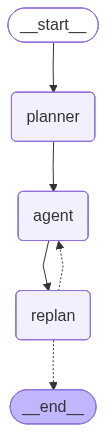

In [12]:
from IPython.display import Image

Image(app.get_graph().draw_mermaid_png())

In [13]:
config = {"recursion_limit": 50}
inputs = {
    "input": "I want 5 must see museums in Helsinki, \
            and what the entrance fee would be if they would \
            still use the Finnish markka"
}
async for event in app.astream(inputs, config=config):
    for k, v in event.items():
        if k != "__end__":
            print(v)

        if "response" in v and v["response"]:
            print("===============================")
            print("\nFinal response:", v["response"])
            break

{'plan': ['List 5 must-see museums in Helsinki.', 'Find the current entrance fee for each museum in euros.', 'Use the historical fixed exchange rate of 1 euro = 5.94573 Finnish markka to convert each entrance fee from euros to Finnish markka.', 'Provide the converted entrance fees alongside the museum names.']}
{'past_steps': [('List 5 must-see museums in Helsinki.', 'Here are 5 must-see museums in Helsinki:\n\n1. Ateneum Art Museum\n2. Kiasma Museum of Contemporary Art\n3. Helsinki City Museum\n4. National Museum of Finland\n5. Design Museum Helsinki\n\nWould you like me to proceed with finding the current entrance fees for these museums?')]}
{'plan': ['Find the current entrance fee for each museum in euros.', 'Use the historical fixed exchange rate of 1 euro = 5.94573 Finnish markka to convert each entrance fee from euros to Finnish markka.', 'Provide the converted entrance fees alongside the museum names.']}
{'past_steps': [('Find the current entrance fee for each museum in euros.',